# CNN on Mnist

In [3]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("MNIST\MNIST\mnist_train.csv")
test_df = pd.read_csv("MNIST\MNIST\mnist_test.csv")


In [4]:
y_train = train_df.iloc[:,0].values
X_train = train_df.iloc[:,1:].values
y_test = test_df.iloc[:,0].values
X_test = test_df.iloc[:,1:].values

In [5]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [6]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
import tensorflow as tf

inputs = Input(shape=(28,28,1))

x = Conv2D(16, (3,3), activation='relu')(inputs)
x = MaxPooling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)
outputs = Dense(10)(x)

cnn_mnist = Model(inputs, outputs)

cnn_mnist.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)


In [7]:
cnn_mnist.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_data=(X_test_cnn, y_test))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9308 - loss: 0.5280 - val_accuracy: 0.9700 - val_loss: 0.1081
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9761 - loss: 0.0840 - val_accuracy: 0.9819 - val_loss: 0.0608
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9809 - loss: 0.0639 - val_accuracy: 0.9790 - val_loss: 0.0660
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9835 - loss: 0.0550 - val_accuracy: 0.9827 - val_loss: 0.0571
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9849 - loss: 0.0493 - val_accuracy: 0.9796 - val_loss: 0.0710
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9864 - loss: 0.0454 - val_accuracy: 0.9834 - val_loss: 0.0579
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9879 - loss: 0.0397 - val_accuracy: 0.9842 - val_loss: 0.0542
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9890 - loss: 0.0380 -

# CNN on TinyImageNet

In [8]:
from tensorflow.keras.utils import image_dataset_from_directory


In [27]:
train_ds = image_dataset_from_directory(
    "tiny-imagenet\\train",
    image_size=(64,64),
    batch_size=32,
    label_mode='int'
)


val_ds = image_dataset_from_directory(
    "tiny-imagenet\\val",
    image_size=(64,64),
    batch_size=32,
    label_mode='int'
)
test_ds = image_dataset_from_directory(
    "tiny-imagenet\\test",
    image_size=(64,64),
    batch_size=32,
    label_mode='int'
)


Found 3500 files belonging to 10 classes.
Found 500 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.


In [30]:
train_ds = train_ds.map(lambda x, y: (x/255.0, y))
val_ds   = val_ds.map(lambda x, y: (x/255.0, y))
test_ds   = test_ds.map(lambda x, y: (x/255.0, y))

In [14]:
inputs = Input(shape=(64,64,3))

x = Conv2D(16, (3,3), activation='relu')(inputs)
x = MaxPooling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)
outputs = Dense(10)(x)

cnn_tiny = Model(inputs, outputs)

cnn_tiny.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)


In [15]:
cnn_tiny.fit(train_ds, epochs=10, validation_data=val_ds)


Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.3120 - loss: 1.7791 - val_accuracy: 0.4280 - val_loss: 1.5997
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4663 - loss: 1.4415 - val_accuracy: 0.4840 - val_loss: 1.4257
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5091 - loss: 1.3112 - val_accuracy: 0.4740 - val_loss: 1.4735
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5709 - loss: 1.2151 - val_accuracy: 0.4780 - val_loss: 1.4377
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5820 - loss: 1.1607 - val_accuracy: 0.5000 - val_loss: 1.3626
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6309 - loss: 1.0469 - val_accuracy: 0.4860 - val_loss: 1.4021
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6634 - loss: 0.9735 - val_accuracy: 0.4820 - val_loss: 1.4296
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6771 - loss: 0.8987 - val_accu

# PART 3.1 — Filter Gallery

# Extract First Conv Layer Weights

## MNIST

In [16]:
mnist_kernels = cnn_mnist.layers[1].get_weights()[0]
print(mnist_kernels.shape)   # (3,3,1,16)

(3, 3, 1, 16)


## Tiny MNIST

In [17]:
tiny_kernels = cnn_tiny.layers[1].get_weights()[0]
print(tiny_kernels.shape)   # (3,3,3,16)

(3, 3, 3, 16)


## Plot MNIST Kernels

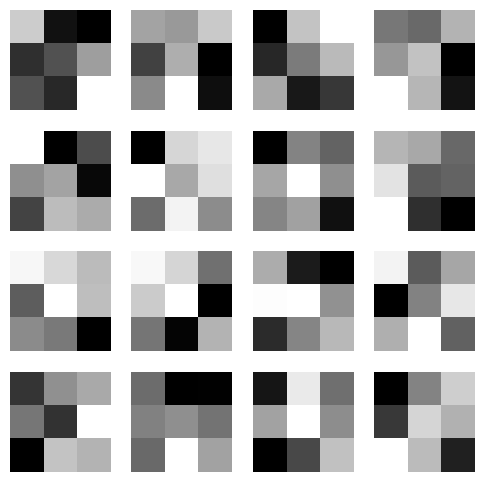

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4,4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(mnist_kernels[:,:,0,i], cmap='gray')
    ax.axis('off')

plt.show()


## Plot Tiny Kernels

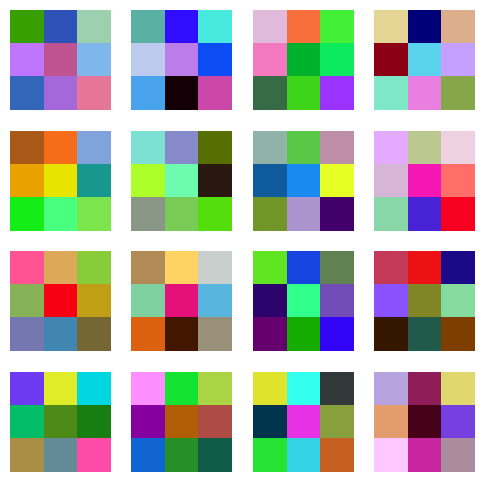

In [19]:
fig, axes = plt.subplots(4,4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    kernel = tiny_kernels[:,:,:,i]
    kernel = (kernel - kernel.min()) / (kernel.max() - kernel.min())
    ax.imshow(kernel)
    ax.axis('off')

plt.show()


# PART 3.2 — Activation Maps

# MNIST Activation Maps

## Select one image

In [20]:
sample_img = X_test[0:1]

## Create intermediate model

In [22]:
from tensorflow.keras.models import Model

activation_model_mnist = Model(
    inputs=cnn_mnist.input,
    outputs=[
        cnn_mnist.layers[1].output,   # first conv
        cnn_mnist.layers[3].output    # second conv
    ]
)
sample_img = sample_img.reshape(1, 28, 28, 1)

activations_mnist = activation_model_mnist.predict(sample_img)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


## Plot First Conv Activations

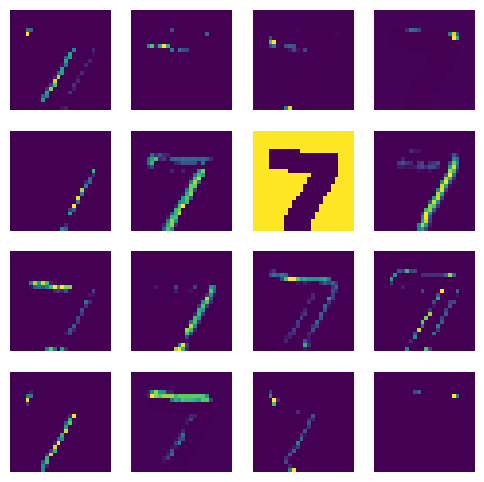

In [23]:
fig, axes = plt.subplots(4,4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(activations_mnist[0][0,:,:,i], cmap='viridis')
    ax.axis('off')

plt.show()


## Plot Final Conv Activations

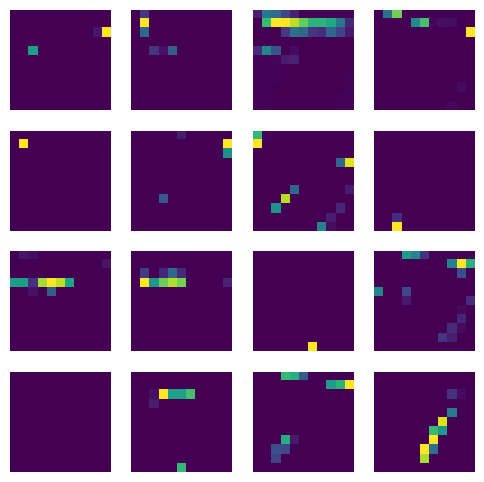

In [24]:
fig, axes = plt.subplots(4,4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(activations_mnist[1][0,:,:,i], cmap='viridis')
    ax.axis('off')

plt.show()


# Tiny Activation Maps

## Select one image

In [31]:
for img, label in test_ds.take(1):
    sample_img_tiny = img[0:1]
    break


## Intermediate model

In [32]:
activation_model_tiny = Model(
    inputs=cnn_tiny.input,
    outputs=[
        cnn_tiny.layers[1].output,
        cnn_tiny.layers[3].output
    ]
)

activations_tiny = activation_model_tiny.predict(sample_img_tiny)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


## Plot First Conv Activations

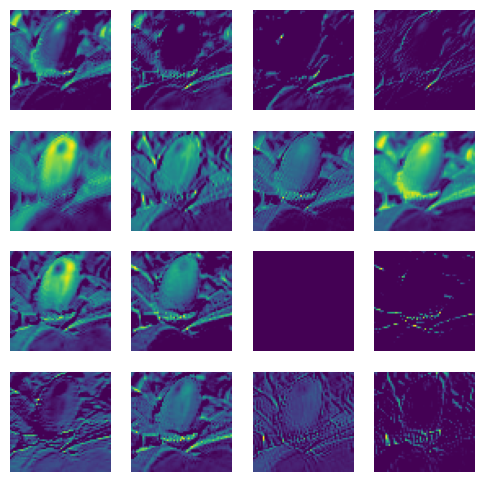

In [33]:
fig, axes = plt.subplots(4,4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(activations_tiny[0][0,:,:,i], cmap='viridis')
    ax.axis('off')

plt.show()


## Plot Final Conv Activations

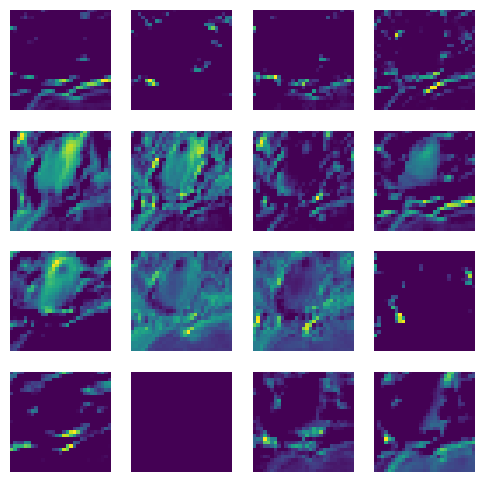

In [34]:
fig, axes = plt.subplots(4,4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(activations_tiny[1][0,:,:,i], cmap='viridis')
    ax.axis('off')

plt.show()
